2025-06-22 13:47:50.012889: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 13:47:50.014158: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-22 13:47:50.017290: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-22 13:47:50.026084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750618070.040949 3056475 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750618070.04

[PID 3057343] Training batch size = 4096
[PID 3057344] Training batch size = 8192
[PID 3057340] Training batch size = 512
[PID 3057342] Training batch size = 2048
[PID 3057339] Training batch size = 256[PID 3057341] Training batch size = 1024[PID 3057337] Training batch size = 64


[PID 3057338] Training batch size = 128


2025-06-22 13:47:53.683274: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-06-22 13:47:53.683309: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES=""
2025-06-22 13:47:53.683318: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2025-06-22 13:47:53.683324: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-06-22 13:47:53.683328: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: kdplab01
2025-06-22 13:47:53.683330: I external/local_xla/xla/stream_executo

Epoch 1/120
Epoch 1/120
Epoch 1/120
Epoch 1/120
Epoch 1/120
Epoch 1/120
Epoch 1/120
Epoch 1/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step - accuracy: 0.2564 - loss: 3.1617 - val_accuracy: 0.5318 - val_loss: 1.1069
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.4497 - loss: 5.0335 - val_accuracy: 0.5563 - val_loss: 1.9214
Epoch 2/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.3292 - loss: 1.7117 - val_accuracy: 0.5709 - val_loss: 0.7666
Epoch 2/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.3748 - loss: 1.4799 - val_accuracy: 0.5102 - val_loss: 0.9109
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.4661 - loss: 2.0197 - val_accuracy: 0.5958 - val_loss: 0.8589
Epoch 3/120
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - accuracy: 0.5139 - loss: 0.9367 - val_accuracy: 0.5089 - val_loss: 0.8379
Epoch 4/120
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5499 - loss: 1.2142 - val_accuracy: 0.5644 - val_loss: 1.0364
Epoch 2/120
30/30 ━━

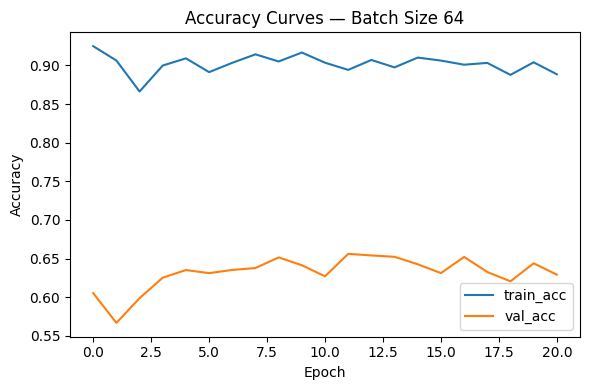

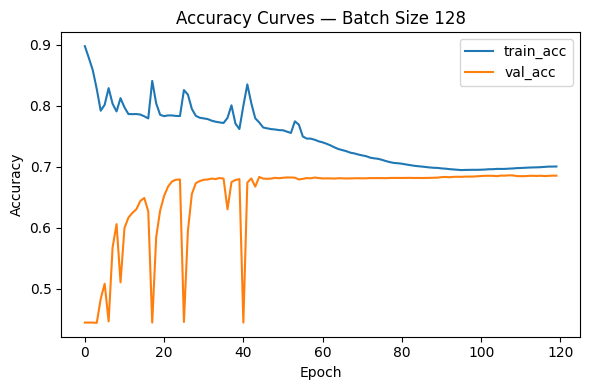

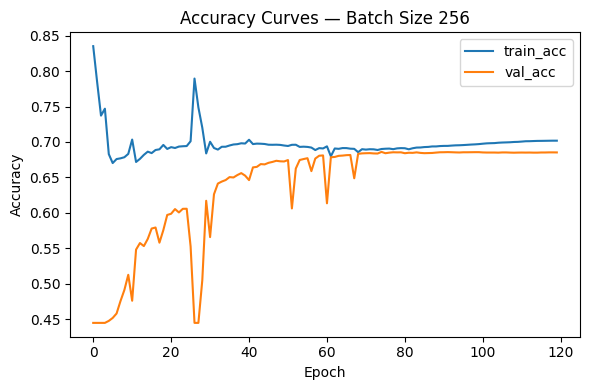

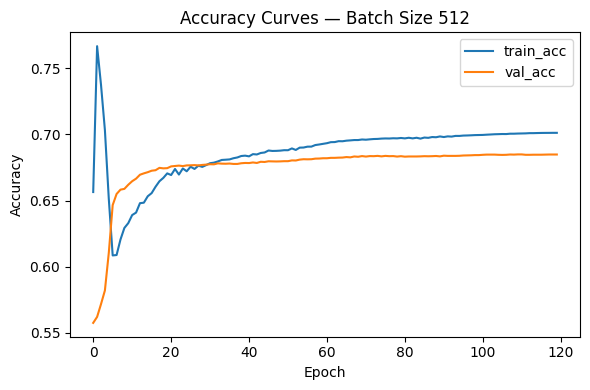

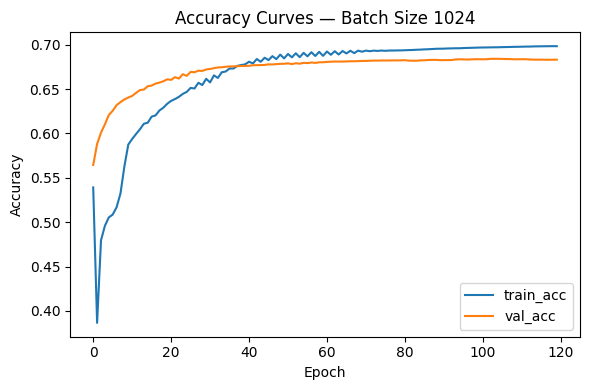

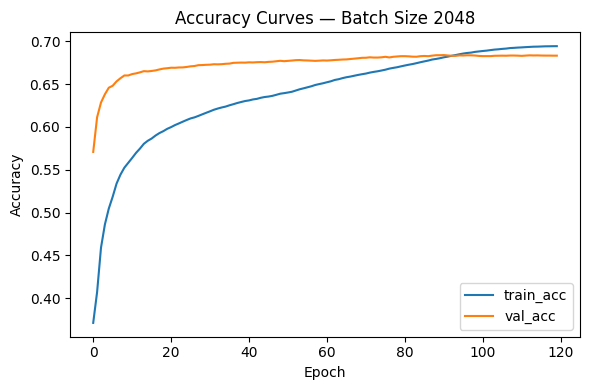

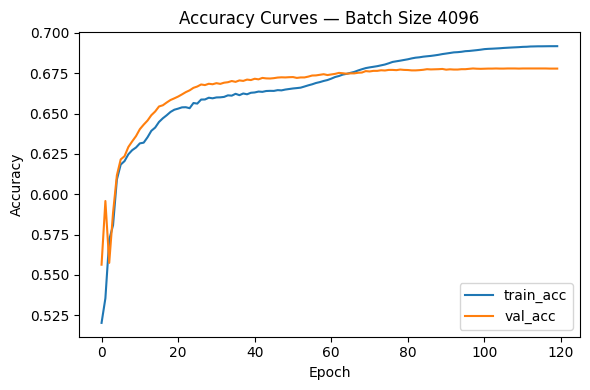

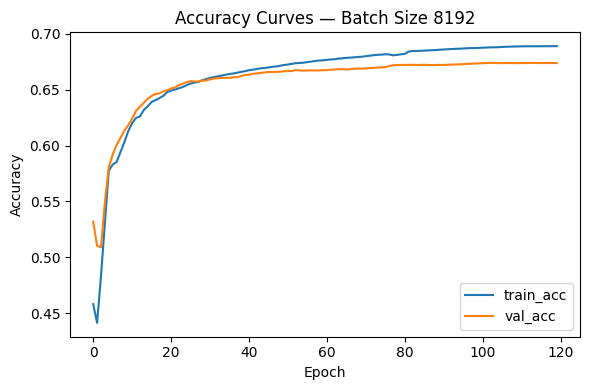

In [1]:
import os
import re
import glob
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed

# ─── 0) Ensure we can import ODG and force CPU-only ──────────────────────────
parentdir = os.path.dirname(os.getcwd())
sys.path.insert(0, parentdir)
os.environ['CUDA_VISIBLE_DEVICES'] = ''

import OptimizedDataGenerator4 as ODG
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ─── 1) Model factory ─────────────────────────────────────────────────────────
def CreateXYProfileModel():
    x_profile = tf.keras.Input(shape=(21, 1), name="x_profile")
    y_profile = tf.keras.Input(shape=(13, 1), name="y_profile")
    x_flat    = tf.keras.layers.Flatten(name="flatten_x")(x_profile)
    y_flat    = tf.keras.layers.Flatten(name="flatten_y")(y_profile)
    concat    = tf.keras.layers.Concatenate(name="concat_xy")([x_flat, y_flat])
    hidden1   = tf.keras.layers.Dense(64, activation="relu", name="hidden_128")(concat)
    hidden2   = tf.keras.layers.Dense(16, activation="relu", name="hidden_32")(hidden1)
    output    = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(hidden2)
    return tf.keras.Model(inputs=[x_profile, y_profile], outputs=output)

# ─── 2) Worker: train & return history ────────────────────────────────────────
def train_for_batch(batch_dir, num_epochs=120, initial_lr=1e-3):
    # parse batch size
    m = re.search(r"Batch(\d+)_", os.path.basename(batch_dir))
    batch_size = int(m.group(1))

    train_dir = os.path.join(batch_dir, "tfrecords_train")
    val_dir   = os.path.join(batch_dir, "tfrecords_validation")

    # data generators
    train_gen = ODG.OptimizedDataGenerator(
        load_records=True,
        tf_records_dir=str(train_dir),
        x_feature_description=["x_profile", "y_profile"],
        batch_size=batch_size
    )
    val_gen = ODG.OptimizedDataGenerator(
        load_records=True,
        tf_records_dir=str(val_dir),
        x_feature_description=["x_profile", "y_profile"],
        batch_size=batch_size
    )

    steps_per_epoch = len(train_gen)
    total_steps     = steps_per_epoch * num_epochs

    # fresh model/context
    tf.keras.backend.clear_session()
    model = CreateXYProfileModel()

    # cosine decay schedule
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=total_steps,
        alpha=0.0
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    es = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

    print(f"[PID {os.getpid()}] Training batch size = {batch_size}")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=num_epochs,
        steps_per_epoch=steps_per_epoch,
        callbacks=[es],
        shuffle=False,
        verbose=1
    )
    return batch_size, history.history

# ─── 3) Main: discover folders, parallelize, collect, then plot ─────────────
if __name__ == "__main__":
    base_dir = "/local/d1/smartpixML/filtering_models/Time19"
    batch_dirs = sorted(
        glob.glob(os.path.join(base_dir, "Batch*_Time19")),
        key=lambda p: int(re.search(r"Batch(\d+)_", os.path.basename(p)).group(1))
    )

    results = {}
    with ProcessPoolExecutor(max_workers=len(batch_dirs)) as executor:
        futures = {executor.submit(train_for_batch, bd): bd for bd in batch_dirs}
        for fut in as_completed(futures):
            bs, hist = fut.result()
            results[bs] = hist

    # plot one accuracy curve per batch size
    for bs in sorted(results):
        h = results[bs]
        plt.figure(figsize=(6,4))
        plt.plot(h["accuracy"],     label="train_acc")
        plt.plot(h["val_accuracy"], label="val_acc")
        plt.title(f"Accuracy Curves — Batch Size {bs}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()
